# 02 — Baseline Machine Learning classique

## 1. Objectif

Comparer Logistic Regression, Linear SVM et Random Forest avec une représentation TF-IDF commune et le split historique inchangé. Aucun Deep Learning n'est exécuté.

## 2. Problème métier

La cible est binaire : `ham` (SMS légitime) ou `spam` (message indésirable ou frauduleux). Un faux positif risque de masquer un message légitime ; un faux négatif laisse un spam atteindre l'utilisateur. Les textes français sont des traductions automatiques, pas des SMS natifs collectés en France.

In [1]:
from pathlib import Path
import hashlib
import os
import sys

candidates = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next(path for path in candidates if (path / 'config/config.yaml').exists())
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import joblib
import pandas as pd
from IPython.display import display, Markdown, Image
from spamguard.ml import MODEL_NAMES, run_ml_experiment

split_path = PROJECT_ROOT / 'data/processed/ml_split_ids.csv'
split_hash_before = hashlib.sha256(split_path.read_bytes()).hexdigest()
experiment = run_ml_experiment()
split_hash_after = hashlib.sha256(split_path.read_bytes()).hexdigest()
assert split_hash_before == split_hash_after == '6d1557cb761f1b271f362767ece08dedc55b2f56d28f496bded8dad4b0c97f87'
before = experiment['before']
deduplicated = experiment['deduplicated']
train = experiment['train']
test = experiment['test']
metrics = experiment['metrics']
print('Split historique inchangé :', split_hash_after)

Split historique inchangé : 6d1557cb761f1b271f362767ece08dedc55b2f56d28f496bded8dad4b0c97f87


## 3. Dataset

Le texte principal est `text_fr`; `text_en` est conservé comme référence. La ponctuation, les chiffres, les URL et les majuscules ne sont pas supprimés, car ils peuvent être informatifs pour le spam.

In [2]:
display(pd.Series({
    'messages initiaux': len(before),
    'ham initiaux': (before['label'] == 'ham').sum(),
    'spam initiaux': (before['label'] == 'spam').sum(),
}).to_frame('nombre'))

,nombre
messages initiaux,5572
ham initiaux,4825
spam initiaux,747


## 4. Déduplication

Le dataset expérimental existant conserve la première occurrence de chaque `text_fr` strictement identique. Le fichier original reste intact. La règle française retire 438 lignes, contre 415 doublons du triplet complet observés lors de l'audit.

In [3]:
display(pd.Series({
    'avant': len(before),
    'après': len(deduplicated),
    'supprimées': len(before) - len(deduplicated),
    'ham après': (deduplicated['label'] == 'ham').sum(),
    'spam après': (deduplicated['label'] == 'spam').sum(),
}).to_frame('nombre'))
assert deduplicated['text_fr'].is_unique

,nombre
avant,5572
après,5134
supprimées,438
ham après,4494
spam après,640


## 5. Split

Aucun nouveau split n'est calculé. Les identifiants existants de `ml_split_ids.csv` sont rechargés : 80 % train, 20 % test, issus du split stratifié à graine 42 de la première expérience.

In [4]:
split_distribution = pd.concat({
    'train': train['label'].value_counts(),
    'test': test['label'].value_counts(),
}, axis=1).T.reindex(columns=['ham', 'spam'])
display(split_distribution.assign(total=lambda frame: frame.sum(axis=1)))
overlap = set(train['text_fr']).intersection(test['text_fr'])
print('Textes identiques entre train et test :', len(overlap))
assert not overlap

label,ham,spam,total
train,3595,512,4107
test,899,128,1027


Textes identiques entre train et test : 0


## 6. TF-IDF

Chaque pipeline possède son propre `TfidfVectorizer`, ajusté uniquement sur le train : `lowercase=True`, `ngram_range=(1, 2)`, `min_df=2`, `max_df=0.95`, `sublinear_tf=True`. Cette configuration simple préserve ponctuation, nombres et URL. Elle est raisonnable, mais non présentée comme optimale.

## 7. Logistic Regression

La régression logistique utilise `class_weight='balanced'`, `max_iter=1000` et le solveur `liblinear`, adapté à une classification binaire sparse et offrant des coefficients inspectables.

,model,accuracy,precision_spam,recall_spam,f1_spam,f1_macro,false_positives,false_negatives,training_time_seconds,inference_time_ms_mean
0,Logistic Regression,0.9815,0.909774,0.945312,0.927203,0.958303,12,7,0.061328,0.007429


              precision    recall  f1-score   support

         ham     0.9922    0.9867    0.9894       899
        spam     0.9098    0.9453    0.9272       128

    accuracy                         0.9815      1027
   macro avg     0.9510    0.9660    0.9583      1027
weighted avg     0.9819    0.9815    0.9817      1027



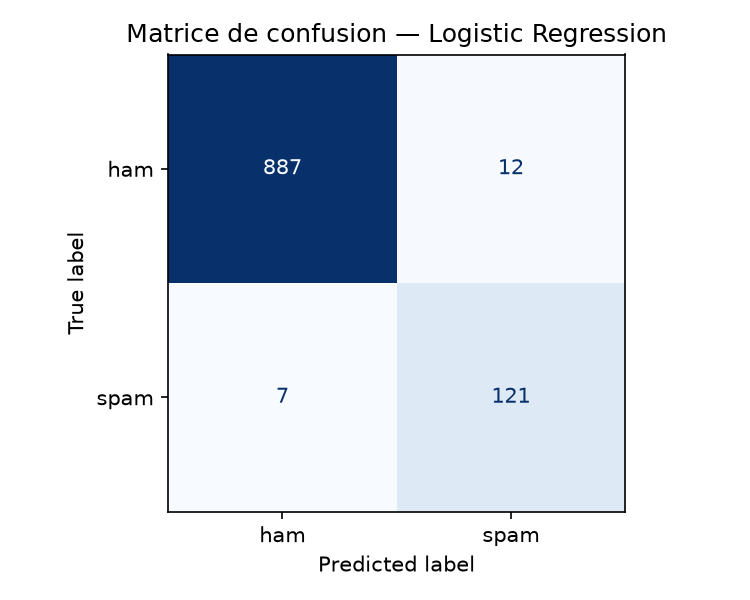

In [5]:
display(metrics.loc[metrics['model'] == 'Logistic Regression'])
print(experiment['classification_reports']['logistic_regression'])
display(Image(filename=str(PROJECT_ROOT / 'outputs/figures/confusion_matrix_logistic_regression.png')))

## 8. Linear SVM

LinearSVC avec pondération équilibrée est adapté aux représentations sparse à haute dimension et couramment efficace en classification de texte. Aucune calibration probabiliste n'est ajoutée.

,model,accuracy,precision_spam,recall_spam,f1_spam,f1_macro,false_positives,false_negatives,training_time_seconds,inference_time_ms_mean
1,Linear SVM,0.986368,0.952381,0.9375,0.944882,0.968552,6,8,0.051185,0.007426


              precision    recall  f1-score   support

         ham     0.9911    0.9933    0.9922       899
        spam     0.9524    0.9375    0.9449       128

    accuracy                         0.9864      1027
   macro avg     0.9718    0.9654    0.9686      1027
weighted avg     0.9863    0.9864    0.9863      1027



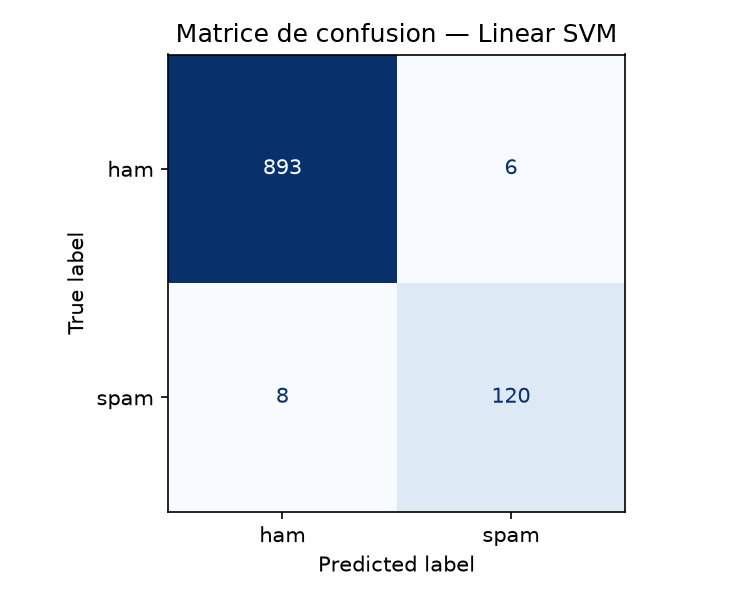

In [6]:
display(metrics.loc[metrics['model'] == 'Linear SVM'])
print(experiment['classification_reports']['linear_svm'])
display(Image(filename=str(PROJECT_ROOT / 'outputs/figures/confusion_matrix_linear_svm.png')))

## 9. Random Forest

RandomForestClassifier représente la famille des algorithmes d'ensemble à base d'arbres étudiée dans la formation. Il utilise 300 arbres, `class_weight='balanced'`, `random_state=42` et les CPU disponibles. Il peut capter des interactions non linéaires, mais n'est pas naturellement optimal pour un TF-IDF sparse de grande dimension et son coût doit être surveillé.

,model,accuracy,precision_spam,recall_spam,f1_spam,f1_macro,false_positives,false_negatives,training_time_seconds,inference_time_ms_mean
2,Random Forest,0.977605,0.92,0.898438,0.909091,0.94816,10,13,0.339655,0.035446


              precision    recall  f1-score   support

         ham     0.9856    0.9889    0.9872       899
        spam     0.9200    0.8984    0.9091       128

    accuracy                         0.9776      1027
   macro avg     0.9528    0.9437    0.9482      1027
weighted avg     0.9774    0.9776    0.9775      1027



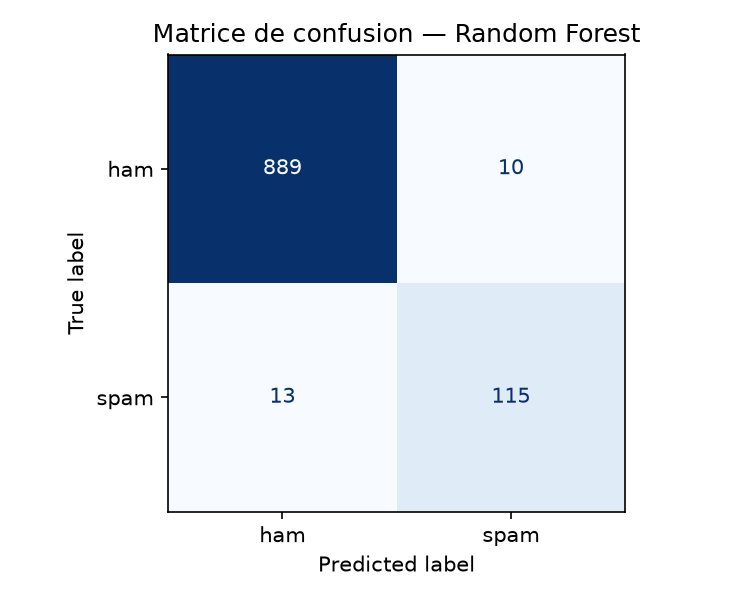

In [7]:
display(metrics.loc[metrics['model'] == 'Random Forest'])
print(experiment['classification_reports']['random_forest'])
display(Image(filename=str(PROJECT_ROOT / 'outputs/figures/confusion_matrix_random_forest.png')))

## 10. Comparaison

Toutes les métriques proviennent du même test historique. `spam` est la classe positive. Les temps moyens d'inférence incluent le TF-IDF et sont mesurés par message sur 20 répétitions du test complet.

,model,accuracy,precision_spam,recall_spam,f1_spam,f1_macro,false_positives,false_negatives,training_time_seconds,inference_time_ms_mean
0,Logistic Regression,0.9815,0.9098,0.9453,0.9272,0.9583,12,7,0.061328,0.007429
1,Linear SVM,0.9864,0.9524,0.9375,0.9449,0.9686,6,8,0.051185,0.007426
2,Random Forest,0.9776,0.9200,0.8984,0.9091,0.9482,10,13,0.339655,0.035446


,model,true_negatives,false_positives,false_negatives,true_positives
0,Logistic Regression,887,12,7,121
1,Linear SVM,893,6,8,120
2,Random Forest,889,10,13,115


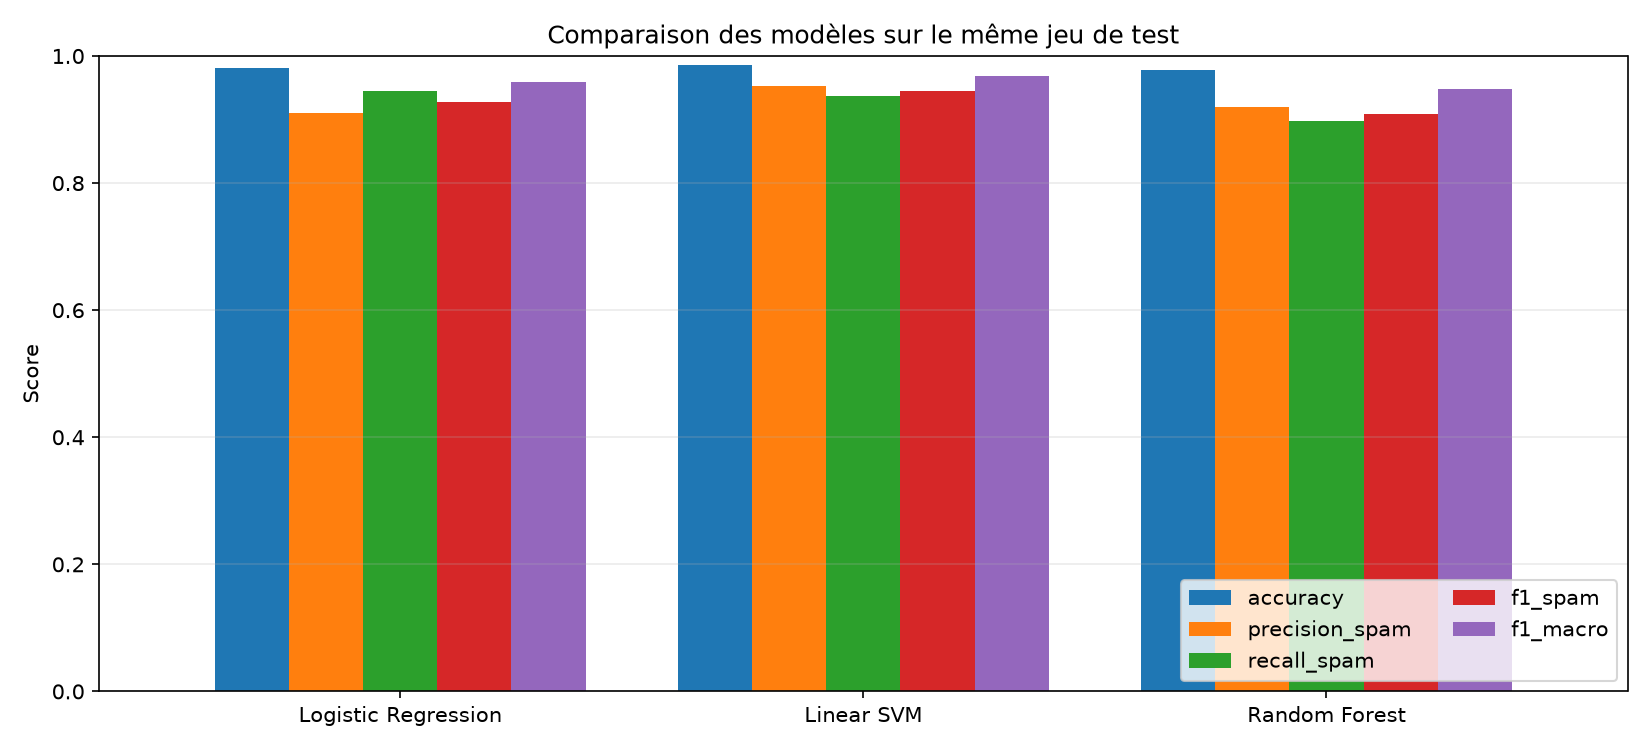

In [8]:
display(metrics.style.format({
    'accuracy': '{:.4f}', 'precision_spam': '{:.4f}', 'recall_spam': '{:.4f}',
    'f1_spam': '{:.4f}', 'f1_macro': '{:.4f}',
    'training_time_seconds': '{:.6f}', 'inference_time_ms_mean': '{:.6f}',
}))
confusion_counts = metrics[['model', 'false_positives', 'false_negatives']].copy()
confusion_counts['true_negatives'] = (test['label'] == 'ham').sum() - confusion_counts['false_positives']
confusion_counts['true_positives'] = (test['label'] == 'spam').sum() - confusion_counts['false_negatives']
display(confusion_counts[['model', 'true_negatives', 'false_positives', 'false_negatives', 'true_positives']])
display(Image(filename=str(PROJECT_ROOT / 'outputs/figures/ml_model_comparison.png')))

## 11. Analyse des erreurs

Les tableaux sont limités à cinq faux positifs et cinq faux négatifs par modèle. L'analyse ne dépasse pas ce qui est directement visible dans les messages.

In [9]:
for key, name in MODEL_NAMES.items():
    display(Markdown(f'### {name} — faux positifs'))
    display(experiment['errors'][key]['false_positives'])
    display(Markdown(f'### {name} — faux négatifs'))
    display(experiment['errors'][key]['false_negatives'])

### Logistic Regression — faux positifs

,id,text_fr,text_en,label,prediction
2,sgfr-005194,Prenez votre temps et profitez de votre dîner...,Ok... Take ur time n enjoy ur dinner...,ham,spam
57,sgfr-004856,Pareil pour u...,Same to u...,ham,spam
117,sgfr-001672,Content de voir votre réponse.,Glad to see your reply.,ham,spam
177,sgfr-002289,Vous n'avez pas d'offre de message,Dont you have message offer,ham,spam
182,sgfr-004488,Miss appel miss appel khelate kintu adversaire...,Miss call miss call khelate kintu opponenter m...,ham,spam


### Logistic Regression — faux négatifs

,id,text_fr,text_en,label,prediction
1,sgfr-002663,Bonjour chéri comment allez-vous aujourd'hui? ...,Hello darling how are you today? I would love ...,spam,ham
22,sgfr-000684,Salut je suis poursuivi. J'ai 20 ans et je tra...,Hi I'm sue. I am 20 years old and work as a la...,spam,ham
250,sgfr-004144,Dans The Simpsons Movie sorti en juillet 2007 ...,In The Simpsons Movie released in July 2007 na...,spam,ham
316,sgfr-004213,L'alerte d'appel manquée. Ces numéros ont appe...,Missed call alert. These numbers called but le...,spam,ham
369,sgfr-001469,Salut son LUCY Hubby aux meetins toute la jour...,Hi its LUCY Hubby at meetins all day Fri & I w...,spam,ham


### Linear SVM — faux positifs

...

,id,text_fr,text_en,label,prediction
1,sgfr-002663,Bonjour chéri comment allez-vous aujourd'hui? ...,Hello darling how are you today? I would love ...,spam,ham
22,sgfr-000684,Salut je suis poursuivi. J'ai 20 ans et je tra...,Hi I'm sue. I am 20 years old and work as a la...,spam,ham
250,sgfr-004144,Dans The Simpsons Movie sorti en juillet 2007 ...,In The Simpsons Movie released in July 2007 na...,spam,ham
316,sgfr-004213,L'alerte d'appel manquée. Ces numéros ont appe...,Missed call alert. These numbers called but le...,spam,ham
369,sgfr-001469,Salut son LUCY Hubby aux meetins toute la jour...,Hi its LUCY Hubby at meetins all day Fri & I w...,spam,ham


### Random Forest — faux positifs

,id,text_fr,text_en,label,prediction
93,sgfr-004678,"Wewa a 130 ans, 255 ans, 128 mb.",Wewa is 130. Iriver 255. All 128 mb.,ham,spam
184,sgfr-000228,Hé compagnie Elama po boudyadhu.,Hey company elama po mudyadhu.,ham,spam
388,sgfr-004824,:-) :-),:-) :-),ham,spam
496,sgfr-002468,Y a-t-il un congé pour le pongal vendredi?Vous...,Is there coming friday is leave for pongal?do ...,ham,spam
518,sgfr-004557,Gettin rdy à l'expédition comp,Gettin rdy to ship comp,ham,spam


### Random Forest — faux négatifs

,id,text_fr,text_en,label,prediction
1,sgfr-002663,Bonjour chéri comment allez-vous aujourd'hui? ...,Hello darling how are you today? I would love ...,spam,ham
22,sgfr-000684,Salut je suis poursuivi. J'ai 20 ans et je tra...,Hi I'm sue. I am 20 years old and work as a la...,spam,ham
199,sgfr-002863,Adulte 18 Contenu Votre vidéo sera bientôt ave...,Adult 18 Content Your video will be with you s...,spam,ham
250,sgfr-004144,Dans The Simpsons Movie sorti en juillet 2007 ...,In The Simpsons Movie released in July 2007 na...,spam,ham
316,sgfr-004213,L'alerte d'appel manquée. Ces numéros ont appe...,Missed call alert. These numbers called but le...,spam,ham


### Observations visibles

Les erreurs du modèle retenu comprennent des faux positifs très courts ou traduits maladroitement et un ham contenant `www.fullonsms.com`. Ses faux négatifs présentent notamment des sollicitations ambiguës, des numéros, une tarification britannique, des restes d'anglais et `#ERREUR!`. Ces éléments illustrent les limites du corpus traduit sans prouver automatiquement la cause de chaque erreur.

## 12. Choix du modèle

La métrique principale reste le **F1 spam**, avec recall spam et faux positifs comme garde-fous. Le modèle est choisi seulement après observation des trois nouvelles séries de résultats, puis documenté dans ADR-002.

In [10]:
winner = metrics.loc[metrics['model'] == experiment['selected_model']].iloc[0]
display(winner.to_frame('valeur'))
reloaded = joblib.load(experiment['model_path'])
reload_predictions = reloaded.predict(test['text_fr'].head(5))
print('Modèle retenu :', experiment['selected_model'])
print('Pipeline rechargé :', set(reload_predictions).issubset({'ham', 'spam'}))

,valeur
model,Linear SVM
accuracy,0.986368
precision_spam,0.952381
recall_spam,0.9375
f1_spam,0.944882
f1_macro,0.968552
false_positives,6
false_negatives,8
training_time_seconds,0.051185
inference_time_ms_mean,0.007426


Modèle retenu : Linear SVM
Pipeline rechargé : True


## 13. Limites

- Corpus français traduit automatiquement, non natif.
- Un seul test historique ; une optimisation future exigera validation croisée ou validation séparée sur le train.
- Paramètres raisonnables mais non optimisés.
- Random Forest n'est pas naturellement adapté aux espaces TF-IDF sparse très dimensionnels.
- Temps propres à cette machine et à sa charge.
- Quasi-doublons non traités.

## 14. Conclusion

Cette comparaison pédagogique couvre deux modèles linéaires et un ensemble d'arbres sur le split original inchangé. Seul le pipeline gagnant est sauvegardé. Aucun Deep Learning ni entraînement TensorFlow n'a été exécuté.